## Initial imports


Make sure you have installed m3gnet: `amspackages install m3gnet`.

In [1]:
import scm.plams as plams
from scm.moliterate import PropertyInfo
from scm.moliterate.analysis import PairwiseDatasetMetrics

from scm.active_learning import ActiveLearningLoop, SimpleActiveLearningJourney
from scm.active_learning.checker_getters.checkers import AMSTrajChecker
from scm.active_learning.checker_getters.getters import AMSTrajGetter
from scm.active_learning.engines import AMSEngine, SCMChemicalSystem
from scm.active_learning.loop import StoppableCounter
from scm.active_learning.mlip.params_trainer import ParAMSTrainer
from scm.active_learning.task_parallelization import AMSParallelCPU
from scm.active_learning.tasks import AMSMDTask, SPLabeller

## Input system


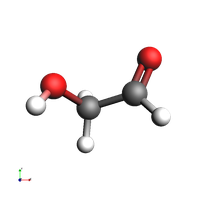

In [2]:
mol = plams.from_smiles("OCC=O")
for at in mol:
    at.properties = {}
plams.view(mol, width=200, height=200)

## Reference engine settings
For time reasons we use the UFF force field as the reference method. Typically you would instead train to DFT using ADF, BAND, or Quantum ESPRESSO.


In [3]:
ref_s = plams.Settings()
ref_s.input.ForceField.Type = "UFF"
ref_s.runscript.nproc = 1

labeller_engine = AMSEngine.from_settings(settings=ref_s, engine_id="UFFRef")

In [4]:
print(plams.AMSJob(settings=labeller_engine.settings).get_input())


Engine ForceField
  Type UFF
EndEngine




## Molecular dynamics settings
Here, we use the `AMSMDTask` to define the molecular dynamics settings directly in the new API.


In [5]:
md_task = AMSMDTask(
    atomistic_system=SCMChemicalSystem.from_molecules(
        system_id="OCC=O",
        systems=mol,
    ),
    nsteps=10000,
    timestep=0.5,
    temperature=300,
    thermostat="NHC",
    samplingfreq=1,
)


In [6]:
print(plams.AMSJob(settings=md_task.settings).get_input())

MolecularDynamics
  BinLog
    DipoleMoment False
    PressureTensor False
    Time False
  End
  CalcPressure False
  Checkpoint
    Frequency 1000
  End
  InitialVelocities
    Temperature 300.0
    Type Random
  End
  NSteps 10000
  Thermostat
    Tau 200.0
    Temperature 300.0
    Type NHC
  End
  TimeStep 0.5
  Trajectory
    SamplingFreq 1
    WriteBonds True
    WriteCharges True
    WriteEngineGradients False
    WriteMolecules True
    WriteVelocities True
  End
End

Task MolecularDynamics




## ParAMS ML Training settings
<a id='MLTrainer'></a>
We start with the M3GNet ParAMS trainer. Otherwise you can switch to the TEST backend in the commented lines for fast tutorial.

In [7]:
mlip_trainer = (
    ParAMSTrainer.Builder.M3GNet_EF(Model="UniversalPotential")
    .set_committee(committee_size=1)
    .set_max_epochs(200)
    .build()
)

# mlip_trainer = (
#     ParAMSTrainer.Builder.TEST()
#     .set_committee(committee_size=1)
#     .build()
# )

print(mlip_trainer.settings)


input: 	
      MachineLearning: 	
                      Backend: 	M3GNet
                      CommitteeSize: 	1
                      M3GNet: 	
                             LearningRate: 	0.001
                             Model: 	UniversalPotential
                      MaxEpochs: 	200
                      RunAMSAtEnd: 	True
      ParallelLevels: 	
                     CommitteeMembers: 	1
      Task: 	MachineLearning



## Journey Scheduler: SimpleActiveLearningJourney

In [8]:
# Compact setup: read md_nsteps/sampling from md_task.settings
step_model = SimpleActiveLearningJourney.GeometricSteps.from_md_settings(
    md_settings=md_task.settings,
    start=100,
    num_steps=5,
    # Optional override; omit to use md_task.settings SamplingFreq
    sampling=100,
    min_frames=30,
)

sal = SimpleActiveLearningJourney(
    checker_getter=AMSTrajChecker() + AMSTrajGetter(),
    task=md_task,
    steps=step_model,
    max_attempts=10,
    first_step_train=True,
    watch_ams_log_stdout=True,
)

print(sal.journey_table())

=================================== JourneyScheduler ===================================
AMSMDTask|OCC=O -> AMSTrajChecker|AMSTrajGetter
  MD NSteps    MD NSteps - Cumulative    MD SamplingFreq    MD MaxFrames    max_attempts
-----------  ------------------------  -----------------  --------------  --------------
        100                       100                  3              33              10
        216                       316                  7              30              10
        684                      1000                 22              31              10
       2162                      3162                 72              30              10
       6838                     10000                100              68              10


## Active Learning Loop


In [9]:
al = ActiveLearningLoop(
    start_engine=labeller_engine,
    journey=sal,
    iterable_loop=StoppableCounter(stop=sal.max_n_steps),
    labeller=SPLabeller(
        parallelization=AMSParallelCPU(maxjobs=5, nproc=1),
        properties=[
            PropertyInfo(name="energy", unit="eV"),
            PropertyInfo(name="forces", unit="eV/Ang"),
        ]
    ),
    labeller_engine=labeller_engine,
    accuracy_checker=PairwiseDatasetMetrics(
        settings=[
            PairwiseDatasetMetrics.PropMetricEv(property="energy", metric="rmse", per_n_atoms=True, target=0.1),
            PairwiseDatasetMetrics.PropMetricEv(property="forces", metric="rmse", target=0.1),
        ]
    ),
    mlip_trainer=mlip_trainer,
)


In [10]:
print(al.settings)

tag: 	
start_engine: 	
             engine_id: 	UFFRef
             type: 	AMSEngine
             source_settings: 	
                             input: 	
                                   ForceField: 	
                                              Type: 	UFF
                             runscript: 	
                                       nproc: 	1
             finetunable: 	False
iterable_loop: 	
              start: 	0
              stop: 	50
              iteration_al: 	0
              reason: 	
journey: 	
        task_parallelization: 	
                             watch_ams_log_stdout: 	False
                             type: 	AMSSerialStrategy
                             nproc: 	None
                             OMP_NUM_THREADS: 	None
        type: 	SimpleActiveLearningJourney
        checker_getter: 	
                       type: 	DecoupledCheckerGetter
                       checker: 	
                               checker_id: 	AMSTrajChecker
                               

## Run the loop


In [11]:
import sys

ActiveLearningLoop.logging_config(
    clean_sinks="YES",
    new_sink=sys.stderr,
    level="INFO",
)

1

Expect to take 10-30 min:

In [12]:
final_engine = al.run()

2026-04-21 15:27:50 | INFO     | AL Loop Folder: ALruns/20260421_152749
2026-04-21 15:27:50 | INFO     | Train Val created: ALruns/20260421_152749/train_validation_AL.db
2026-04-21 15:27:50 | INFO     | 
=================================== JourneyScheduler ===================================
AMSMDTask|OCC=O -> AMSTrajChecker|AMSTrajGetter
  MD NSteps    MD NSteps - Cumulative    MD SamplingFreq    MD MaxFrames    max_attempts
-----------  ------------------------  -----------------  --------------  --------------
        100                       100                  3              33              10
        216                       316                  7              30              10
        684                      1000                 22              31              10
       2162                      3162                 72              30              10
       6838                     10000                100              68              10
2026-04-21 15:27:50 | INFO     | Man

In [13]:
al.analysis.get_summary()

{'Reason': 'AL stopped: CONVERGED',
 'NSteps': 19,
 'Ninit': 0,
 'Nfinal': 21,
 'Tot[min]': 17}

In [14]:
print(plams.AMSJob(settings=final_engine.settings).get_input())


Engine MLPotential
  Backend M3GNet
  MLDistanceUnit angstrom
  MLEnergyUnit eV
  Model Custom
  ParameterDir /home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_152749/iter_16/ParAMSTrainer/results/optimization/m3gnet/m3gnet
EndEngine




# Next Steps

Take a look at the results and inspect the simulation:

- __[sal-2-single_molecule_results.ipynb](sal-2-single_molecule_results.ipynb)__

Or run a more realistic simulation by switching trainer: [ParAMS ML Training settings](#MLTrainer)